In [1]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

W1022 11:22:16.810000 45277 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [2]:
import pandas as pd
df = pd.read_csv("analysis_dataset.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
# Only these text columns should be merged
text_cols = [
    'inspiration', 
    'what_it_does', 
    'how_we_built_it', 
    'challenges', 
    'accomplishments', 
    'what_we_learned',
    'what_is_next',
    'tech_stack'
]

# Combine selected columns into one text column
df['all_text'] = df[text_cols].astype(str).apply(lambda x: ' '.join(x), axis=1)

# Clean up text (remove 'nan', brackets, double spaces)
df['all_text'] = (
    df['all_text']
    .str.replace(r"\bnan\b", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
# Drop rows with missing values (optional)
df_ml = df.dropna(subset=['github_summary', 'all_text'])
df_ml['text'] = df_ml['github_summary'] + ' ' + df_ml['all_text']
df_ml['label'] = df_ml['is_winner'].astype(int)
df_ml

,hackathon_name,project_name,project_link,is_winner,inspiration,what_it_does,how_we_built_it,challenges,accomplishments,what_we_learned,what_is_next,tech_stack,external_links,github_links,github_summary,all_text,text,label
0,Cal Hacks 10.0,Audiogroph,https://devpost.com/software/audiogroph,False,With covid ending and people finding new music...,"The project shows events, creators and any NFT...",We used react to build it in vscode and collab...,We had to learn react and navigate through git...,We have successfully built the frontend of the...,Start planning earlier and commit to branches ...,We need a backend to our project.,"css3, html5, javascript, react",['https://github.com/RyanGertz/CalHacksproject'],['https://github.com/RyanGertz/CalHacksproject'],"The GitHub repository, ""CalHacksproject,"" is a...",With covid ending and people finding new music...,"The GitHub repository, ""CalHacksproject,"" is a...",0
1,Cal Hacks 10.0,Let It Out,https://devpost.com/software/let-it-out-b2xp8u,False,Understanding and expressing emotions can be a...,The user is first prompted to record a vocal b...,Let It Out is a full stack web app. The front ...,The main challenges we ran into came in our fi...,NaN,We learned how to integrate modern technologie...,NaN,"chakra, flask, hume, mongodb, node.js, openai,...","['https://github.com/apolyeti/calhacks10.0,', ...",['https://github.com/apolyeti/calhacks10.0'],"This repository, named `calhacks10.0`, serves ...",Understanding and expressing emotions can be a...,"This repository, named `calhacks10.0`, serves ...",0
2,Cal Hacks 10.0,Mood Theremin,https://devpost.com/software/mood-theremin,False,"The theremin, an electronic musical instrument...",Mood Theremin translates your facial expressio...,Our project integrates facial expression analy...,NaN,NaN,NaN,NaN,"css, flask, html, hume, javascript, json, pyth...",['https://github.com/Sepulchre49/CalHacks23'],['https://github.com/Sepulchre49/CalHacks23'],The Mood-Theremin repository details a CalHack...,"The theremin, an electronic musical instrument...",The Mood-Theremin repository details a CalHack...,0
3,Cal Hacks 10.0,Bay Area Safer Housing (B.A.S.H.),https://devpost.com/software/bay-area-safer-ho...,False,The inspiration initially stems from one membe...,B.A.S.H. searches for affordable housing optio...,Our website's foundation was built on next.js ...,Our difficulties lay in our inexperience with ...,"Conceptually, we believe that our project is m...",We've learned most importantly how to better a...,We are serious in our project and are intent o...,"catalog.data.gov, data.sfgov.org, google-maps,...","['https://github.com/matthewaol/b.a.s.h.,']",['https://github.com/matthewaol/b.a.s.h.'],b.a.s.h. (Bay Area Safer Housing) is a CalHack...,The inspiration initially stems from one membe...,b.a.s.h. (Bay Area Safer Housing) is a CalHack...,0
4,Cal Hacks 10.0,PawPals,https://devpost.com/software/pawpals-bd8njs,False,"As college students, we both agreed that fun t...","Based on a list of criteria, we prompt OpenAI'...","On the front-end, we utilized Figma to develop...",Some challenges we ran into were the lack of e...,"As a team of two, we were very proud of our fi...",We learned the value of coming up with a plan ...,We hope to deploy the site on Vercel and devel...,"fastapi, figma, openai, python, react.js, sqlite",['https://github.com/Yatsz/PawPals'],['https://github.com/Yatsz/PawPals'],This analysis summarizes the GitHub repository...,"As college students, we both agreed that fun t...",This analysis summarizes the GitHub repository...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1982,VTHacks 12,Real Estate Analyzer,https://devpost.com/software/real-estate-analy...,False,Our project was inspired by the movieThe Big S...,NaN,NaN,NaN,NaN,NaN,NaN,"azure, git, github, placesapi, react, rest, sql",['https://github.com/lakshya46jain/Real-Estate...,['https://github.com/lakshya46jain/Real-Estate...,"This repository, `real_estat

In [3]:
candidate_labels = ["Winner", "Not Winner"]

In [4]:
from tqdm import tqdm

predictions = []

for text in tqdm(df_ml['text'], desc="Zero-Shot Predictions"):
    result = pipe(text, candidate_labels=candidate_labels)
    # Take the top predicted label
    predictions.append(result['labels'][0])


Zero-Shot Predictions:   3%|▍               | 51/1987 [01:41<1:04:19,  1.99s/it]


KeyboardInterrupt: 

Zero-Shot Predictions (10 rows): 100%|████████| 100/100 [03:13<00:00,  1.93s/it]

Text 1: Not Winner
Text 2: Winner
Text 3: Not Winner
Text 4: Winner
Text 5: Winner
Text 6: Not Winner
Text 7: Winner
Text 8: Winner
Text 9: Winner
Text 10: Winner
Text 11: Winner
Text 12: Winner
Text 13: Not Winner
Text 14: Not Winner
Text 15: Not Winner
Text 16: Winner
Text 17: Winner
Text 18: Not Winner
Text 19: Winner
Text 20: Winner
Text 21: Winner
Text 22: Winner
Text 23: Winner
Text 24: Winner
Text 25: Winner
Text 26: Winner
Text 27: Winner
Text 28: Winner
Text 29: Winner
Text 30: Winner
Text 31: Not Winner
Text 32: Winner
Text 33: Winner
Text 34: Winner
Text 35: Winner
Text 36: Winner
Text 37: Winner
Text 38: Winner
Text 39: Winner
Text 40: Winner
Text 41: Winner
Text 42: Winner
Text 43: Winner
Text 44: Not Winner
Text 45: Winner
Text 46: Winner
Text 47: Winner
Text 48: Not Winner
Text 49: Winner
Text 50: Winner
Text 51: Winner
Text 52: Winner
Text 53: Winner
Text 54: Winner
Text 55: Winner
Text 56: Winner
Text 57: Not Winner
Text 58: Not Winner
Text 59: Winner
Text 60: Winner
T

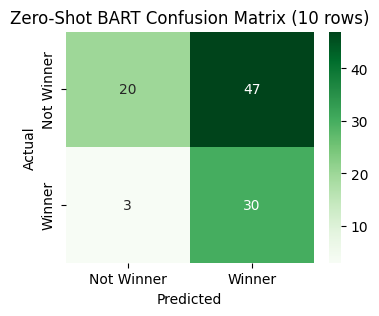

In [6]:
from tqdm import tqdm

predictions = []

# Take first 10 rows for testing
for text in tqdm(df_ml['text'][:100], desc="Zero-Shot Predictions (10 rows)"):
    result = pipe(text, candidate_labels=candidate_labels)
    predictions.append(result['labels'][0])

# Optional: see results
for i, pred in enumerate(predictions):
    print(f"Text {i+1}: {pred}")

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to numeric
pred_numeric = [1 if x == "Winner" else 0 for x in predictions]

# True labels for first 10 rows
y_true = df_ml['label'][:100].astype(int)

# Accuracy and classification report
print("Accuracy:", accuracy_score(y_true, pred_numeric))
print(classification_report(y_true, pred_numeric, target_names=["Not Winner", "Winner"]))

# Confusion matrix
cm = confusion_matrix(y_true, pred_numeric)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Not Winner", "Winner"],
            yticklabels=["Not Winner", "Winner"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Zero-Shot BART Confusion Matrix (10 rows)")
plt.show()


In [ ]:
df_ml['pred_label'] = [1 if x == "Winner" else 0 for x in predictions]

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = df_ml['label']
y_pred = df_ml['pred_label']

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["Not Winner", "Winner"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Not Winner", "Winner"],
            yticklabels=["Not Winner", "Winner"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Zero-Shot BART Confusion Matrix")
plt.show()